<a href="https://colab.research.google.com/github/adithyaashok10/AI-ML-Intership/blob/main/NLP_Lab_Task_day05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/content/final_dataset.csv')

In [22]:
df.head(5)

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [23]:
df['text_lower'] = df['text'].str.lower()
display(df[['text', 'text_lower']].head())

,text,text_lower
0,i feel rather funny ending with so many dupes ...,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result,i feel surprised by the result
2,i am officially feeling festive,i am officially feeling festive
3,i suddenly found myself standing before this w...,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...,i look at the meager pile of food i purchased ...


In [24]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [25]:
df['tokens'] = df['text_lower'].apply(nltk.word_tokenize)
display(df[['text_lower', 'tokens']].head())

,text_lower,tokens
0,i feel rather funny ending with so many dupes ...,"[i, feel, rather, funny, ending, with, so, man..."
1,i feel surprised by the result,"[i, feel, surprised, by, the, result]"
2,i am officially feeling festive,"[i, am, officially, feeling, festive]"
3,i suddenly found myself standing before this w...,"[i, suddenly, found, myself, standing, before,..."
4,i look at the meager pile of food i purchased ...,"[i, look, at, the, meager, pile, of, food, i, ..."


In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
df['tokens_filtered'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])
display(df[['tokens', 'tokens_filtered']].head())

,tokens,tokens_filtered
0,"[i, feel, rather, funny, ending, with, so, man...","[feel, rather, funny, ending, many, dupes, alw..."
1,"[i, feel, surprised, by, the, result]","[feel, surprised, result]"
2,"[i, am, officially, feeling, festive]","[officially, feeling, festive]"
3,"[i, suddenly, found, myself, standing, before,...","[suddenly, found, standing, woman, dressed, li..."
4,"[i, look, at, the, meager, pile, of, food, i, ...","[look, meager, pile, food, purchased, week, fe..."


In [28]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()
df['tokens_stemmed'] = df['tokens_filtered'].apply(lambda x: [ps.stem(word) for word in x])
display(df[['tokens_filtered', 'tokens_stemmed']].head(10))

,tokens_filtered,tokens_stemmed
0,"[feel, rather, funny, ending, many, dupes, alw...","[feel, rather, funni, end, mani, dupe, alway, ..."
1,"[feel, surprised, result]","[feel, surpris, result]"
2,"[officially, feeling, festive]","[offici, feel, festiv]"
3,"[suddenly, found, standing, woman, dressed, li...","[suddenli, found, stand, woman, dress, like, p..."
4,"[look, meager, pile, food, purchased, week, fe...","[look, meager, pile, food, purchas, week, feel..."
5,"[,, one, ,, thrilled, christ, works, outside, ...","[,, one, ,, thrill, christ, work, outsid, time..."
6,"[hate, power, make, feel, ugly, things]","[hate, power, make, feel, ugli, thing]"
7,"[feel, like, missed]","[feel, like, miss]"
8,"[personally, experienced, gut, wrenching, feel...","[person, experienc, gut, wrench, feel, kick, l..."
9,"[hate, feeling, people, see, ugly, know, got, ...","[hate, feel, peopl, see, ugli, know, got, some..."


In [29]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [30]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
df['tokens_lemmatized'] = df['tokens_filtered'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
display(df[['tokens_stemmed', 'tokens_lemmatized']].head(10))

,tokens_stemmed,tokens_lemmatized
0,"[feel, rather, funni, end, mani, dupe, alway, ...","[feel, rather, funny, ending, many, dupe, alwa..."
1,"[feel, surpris, result]","[feel, surprised, result]"
2,"[offici, feel, festiv]","[officially, feeling, festive]"
3,"[suddenli, found, stand, woman, dress, like, p...","[suddenly, found, standing, woman, dressed, li..."
4,"[look, meager, pile, food, purchas, week, feel...","[look, meager, pile, food, purchased, week, fe..."
5,"[,, one, ,, thrill, christ, work, outsid, time...","[,, one, ,, thrilled, christ, work, outside, t..."
6,"[hate, power, make, feel, ugli, thing]","[hate, power, make, feel, ugly, thing]"
7,"[feel, like, miss]","[feel, like, missed]"
8,"[person, experienc, gut, wrench, feel, kick, l...","[personally, experienced, gut, wrenching, feel..."
9,"[hate, feel, peopl, see, ugli, know, got, some...","[hate, feeling, people, see, ugly, know, got, ..."


In [31]:
from sklearn.feature_extraction.text import CountVectorizer

df['text_lemmatized_joined'] = df['tokens_lemmatized'].apply(lambda x: ' '.join(x))

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['text_lemmatized_joined'])

print('Vocabulary size:', len(vectorizer.vocabulary_))

print('\nFeature Names (first 100):', vectorizer.get_feature_names_out()[:100])

print('\nSample of the CountVectorizer Matrix (first 5 rows, few columns):')
display(pd.DataFrame(X.toarray()[:5, :10], columns=vectorizer.get_feature_names_out()[:10]))

print('\nShape of the CountVectorizer Matrix:', X.shape)

Vocabulary size: 39814

Feature Names (first 100): ['00' '000' '000calories' '000shs' '000th' '000ème' '00pm' '01'
 '0235299130' '04' '05' '0512' '06' '08' '09' '0_o' '0l' '0ntworpen' '0w'
 '10' '100' '1000' '10000000000' '100000000000000000000000000000000000'
 '1000x' '100msg' '100th' '100x' '101' '1017' '102' '10373629' '103f'
 '105' '1080' '109' '10am' '10h' '10k' '10mins' '10mm' '10pm' '10puntos'
 '10ritengono' '10th' '10year' '11' '110' '1100' '110km' '1155hours'
 '11am' '11pm' '11th' '12' '120' '120mm' '122' '123' '128' '12am' '12days'
 '12hours' '12hr' '12k' '12pm' '12th' '12x' '13' '1300' '130am' '1330'
 '135' '138' '13gigs' '13th' '13yo' '14' '140' '1400th' '145' '147' '14h'
 '14m' '14th' '14yr' '15' '150' '1500' '15h' '15h20' '15hrs' '15minutes'
 '15th' '16' '160' '165' '16th' '16yo' '17']

Sample of the CountVectorizer Matrix (first 5 rows, few columns):


,00,000,000calories,000shs,000th,000ème,00pm,01,0235299130,04
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0



Shape of the CountVectorizer Matrix: (106355, 39814)


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(df['text_lemmatized_joined'])

print('TF-IDF Vocabulary size:', len(tfidf_vectorizer.vocabulary_))

print('\nTF-IDF Feature Names (first 100):', tfidf_vectorizer.get_feature_names_out()[:100])

print('\nSample of the TF-IDF Matrix (first 5 rows, few columns):')
display(pd.DataFrame(X_tfidf.toarray()[:5, :10], columns=tfidf_vectorizer.get_feature_names_out()[:10]))

print('\nShape of the TF-IDF Matrix:', X_tfidf.shape)

TF-IDF Vocabulary size: 39814

TF-IDF Feature Names (first 100): ['00' '000' '000calories' '000shs' '000th' '000ème' '00pm' '01'
 '0235299130' '04' '05' '0512' '06' '08' '09' '0_o' '0l' '0ntworpen' '0w'
 '10' '100' '1000' '10000000000' '100000000000000000000000000000000000'
 '1000x' '100msg' '100th' '100x' '101' '1017' '102' '10373629' '103f'
 '105' '1080' '109' '10am' '10h' '10k' '10mins' '10mm' '10pm' '10puntos'
 '10ritengono' '10th' '10year' '11' '110' '1100' '110km' '1155hours'
 '11am' '11pm' '11th' '12' '120' '120mm' '122' '123' '128' '12am' '12days'
 '12hours' '12hr' '12k' '12pm' '12th' '12x' '13' '1300' '130am' '1330'
 '135' '138' '13gigs' '13th' '13yo' '14' '140' '1400th' '145' '147' '14h'
 '14m' '14th' '14yr' '15' '150' '1500' '15h' '15h20' '15hrs' '15minutes'
 '15th' '16' '160' '165' '16th' '16yo' '17']

Sample of the TF-IDF Matrix (first 5 rows, few columns):


,00,000,000calories,000shs,000th,000ème,00pm,01,0235299130,04
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Shape of the TF-IDF Matrix: (106355, 39814)


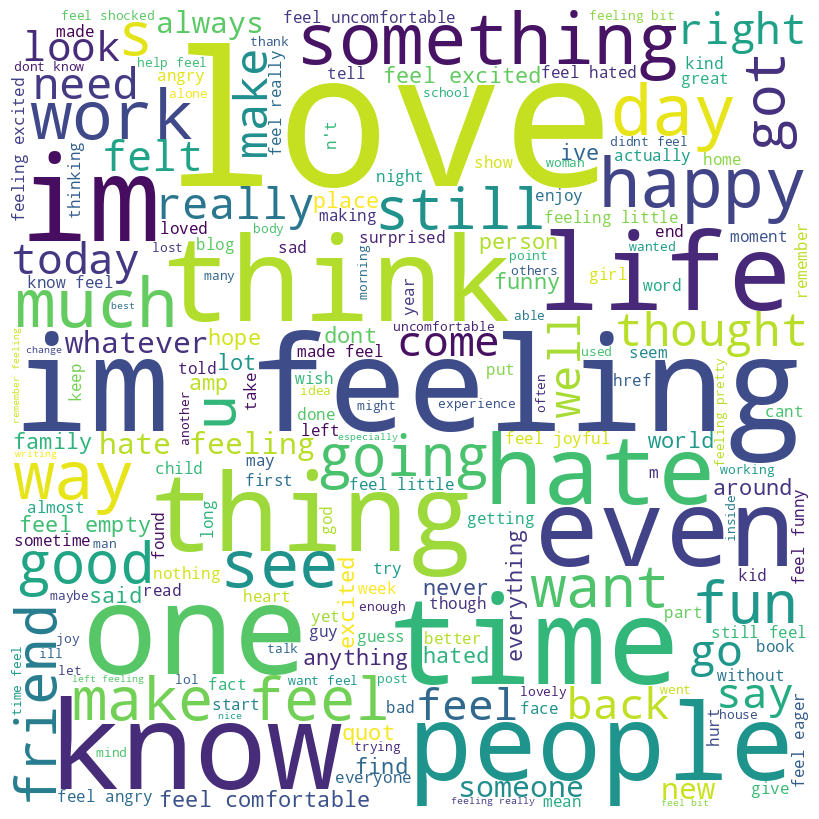

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(df['text_lemmatized_joined'])

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate(all_words)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()